Loading necessary libraries

In [2]:
import json
import string
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

import numpy as np

import seaborn as sns
import warnings #ignored warnings for cleaner outputs
warnings.filterwarnings('ignore')
from collections import OrderedDict
from datetime import datetime

Loading the data

In [1]:
import pandas as pd

# Load the CSV
y_df = pd.read_csv("Datasets/yt_comments.csv")

# Count total unique comments
unique_comments = y_df['comment_id'].nunique()

# Count total replies (non-null reply_id)
total_replies = y_df['reply_id'].notna().sum()

# Average replies per comment
avg_replies = total_replies / unique_comments if unique_comments else 0

# Total videos
total_videos = y_df['video_id'].nunique()

print(f"Total Unique Comments: {unique_comments}")
print(f"Total Replies: {total_replies}")
print(f"Average Replies per Comment: {avg_replies:.2f}")
print(f"Total Videos: {total_videos}")
print(f"Total Combined Data Points (Comments + Replies): {unique_comments + total_replies}")

y_df

Total Unique Comments: 2085
Total Replies: 2597
Average Replies per Comment: 1.25
Total Videos: 63
Total Combined Data Points (Comments + Replies): 4682


,video_id,video_title,video_like_count,video_view_count,comment_id,author,comment,timestamp,comment_like_count,reply_count,reply_id,reply_text,reply_author,reply_published
0,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,UgzBbjwRou6cSNwX9Ot4AaABAg,@Recondo1967,Amazing content. I’m going to Bali this year s...,2025-01-01 19:24:46,3,2,UgzBbjwRou6cSNwX9Ot4AaABAg.AClMa4zgQZyAClOCW6z5gW,You absolutely should! I hope you have a great...,@KevinEassa,2025-01-01T19:38:53Z
1,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,UgzBbjwRou6cSNwX9Ot4AaABAg,@Recondo1967,Amazing content. I’m going to Bali this year s...,2025-01-01 19:24:46,3,2,UgzBbjwRou6cSNwX9Ot4AaABAg.AClMa4zgQZyAEfI3Hk07ez,"try getting a travel guide before going, wishi...",@abolajiibrahim299,2025-02-18T03:52:32Z
2,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,Ugzdznl-nh_LZLIdsoh4AaABAg,@bestplaces_to_visit,"This video is stunning. After watching, does a...",2025-03-01 03:48:16,3,0,NaN,NaN,NaN,NaN
3,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,UgwSzhkR3E0iHPZ6kQx4AaABAg,@dxnsheger972,"Im planning to visit Georgia,Malaysia,Turkey a...",2025-03-29 19:58:46,2,1,UgwSzhkR3E0iHPZ6kQx4AaABAg.AGGRdK1uQMTAGQ2qtIYLy6,That’s going to be an amazing trip!,@KevinEassa,2025-04-02T13:34:34Z
4,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,UgxL7G8ahHsF5naHmJ94AaABAg,@breezydaysahead,Happy new year! 2025 is gonna be sick,2025-01-01 17:48:00,2,1,UgxL7G8ahHsF5naHmJ94AaABAg.AClBWMXLvThAClHWiIKu6o,Can’t wait to see what all we get up to ❤️,@KevinEassa,2025-01-01T18:40:28Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4044,lToZ-Fx4Dro,Top 10 Countries I Want to Visit Someday,5,111,Ugh_EZBch1kisngCoAEC,@opheliatellsstories8360,"traveling is sooo good, I love this! :) xx",2015-08-23 16:12:53,1,1,Ugh_EZBch1kisngCoAEC.83CMn9O6dSs7-HyLfLSkfg,Thanks!(:,@AShootingStar434,2015-08-24T01:04:04Z
4045,lToZ-Fx4Dro,Top 10 Countries I Want to Visit Someday,5,111,UghUgsKBAFcRWHgCoAEC,@KenzieLillian,I would love to go to almost all of these plac...,2015-08-23 04:34:37,1,1,UghUgsKBAFcRWHgCoAEC.83B6sv2l0vF7-H4ALnRLTL,+KenzieLillian I always wanted to go to Italy xDD,@AShootingStar434,2015-08-23T05:06:11Z
4046,lToZ-Fx4Dro,Top 10 Countries I Want to Visit Someday,5,111,UgjQYyTlR-aiFXgCoAEC,@brianat1570,Love this so much.,2015-08-22 23:33:00,1,1,UgjQYyTlR-aiFXgCoAEC.83A_MlzHH3B7-H1h8aglk1,Thanks!(:,@AShootingStar434,2015-08-22T23:42:58Z
4047,lToZ-Fx4Dro,Top 10 Countries I Want to Visit Someday,5,111,Ugj6MAdXVuG_ZHgCoAEC,@kenzierules1207,London and Australia are my top places,2015-08-25 06:53:49,1,0,NaN,NaN,NaN,NaN


In [4]:
# File paths
file_paths = ["Datasets/solotravel_data.json", "Datasets/travel_data.json", "Datasets/best_countries_to_visit_results.json"]


# Track unique posts by their title
unique_posts = OrderedDict()

# Load and combine unique posts by title
for path in file_paths:
    with open(path, 'r') as f:
        data = json.load(f)
        for post in data.get("submissions", []):
            title = post.get("title", "").strip()
            if title and title not in unique_posts:
                unique_posts[title] = post  # retain original structure

# Final combined list
combined_data = {"submissions": list(unique_posts.values())}


# Save to output JSON
with open("Datasets/combined_unique_reddit_posts.json", "w") as f:
    json.dump(combined_data, f, indent=2)

# Summary stats
total_posts = len(combined_data["submissions"])
total_comments = sum(len(post.get("comments", [])) for post in combined_data["submissions"])

print(f"Unique Combined Posts: {total_posts}")
print(f"Total Comments: {total_comments}")
print(f"Average Comments per Post: {total_comments / total_posts:.2f}")
print(f"Total Combined Data Points: {total_posts + total_comments}")


Unique Combined Posts: 1428
Total Comments: 164248
Average Comments per Post: 115.02
Total Combined Data Points: 165676


Making a dataframe for reddit 

In [16]:
# Load the combined Reddit JSON
with open("Datasets/combined_unique_reddit_posts.json", "r") as f:
    data = json.load(f)

# Flatten posts and comments
rows = []
for post in data["submissions"]:
    post_id = post.get("id")
    title = post.get("title", "")
    selftext = post.get("selftext", "")
    score = post.get("score", 0)
    author = post.get("author", "N/A")
    created_utc = post.get("created_utc", 0)
    created_time = datetime.utcfromtimestamp(created_utc)
    year = created_time.year
    comments = post.get("comments", [])

    for comment in comments:
        rows.append({
            "post_id": post_id,
            "post_title": title,
            "post_text": selftext,
            "post_score": score,
            "post_author": author,
            "post_created_utc": created_utc,
            "post_created_time": created_time,
            "year": year,
            "comment_author": comment.get("author", "N/A"),
            "comment_body": comment.get("body", ""),
            "comment_created_utc": comment.get("created_utc", 0),
            "comment_created_time": datetime.utcfromtimestamp(comment["created_utc"])
        })

# Create DataFrame
df = pd.DataFrame(rows)

In [17]:
df

,post_id,post_title,post_text,post_score,post_author,post_created_utc,post_created_time,year,comment_author,comment_body,comment_created_utc,comment_created_time
0,1km2442,Seeking First-Time Female Solo Travel Recommen...,Hi everyone! I (25F) am based in New York City...,2,Front-Memory-7241,1.747183e+09,2025-05-14 00:35:29,2025,AutoModerator,OP appears to have requested personal experien...,1.747183e+09,2025-05-14 00:35:30
1,1km2442,Seeking First-Time Female Solo Travel Recommen...,Hi everyone! I (25F) am based in New York City...,2,Front-Memory-7241,1.747183e+09,2025-05-14 00:35:29,2025,AutoModerator,"Hey, it looks like you have travel safety conc...",1.747183e+09,2025-05-14 00:35:30
2,1km2442,Seeking First-Time Female Solo Travel Recommen...,Hi everyone! I (25F) am based in New York City...,2,Front-Memory-7241,1.747183e+09,2025-05-14 00:35:29,2025,vinsmokesanji3,"If safety is your number 1 priority, why not a...",1.747212e+09,2025-05-14 08:47:25
3,1km4xdq,Need clarification on Schengen 90/180 day trav...,18M dual Canadian/US citizen. Planning a 6 mon...,1,AutomaticOil3119,1.747192e+09,2025-05-14 02:59:15,2025,AutoModerator,It looks like you're planning a trip around Eu...,1.747192e+09,2025-05-14 02:59:16
4,1km6njw,Booked My First International Solo Trip to Gua...,I just booked my first international solo trip...,2,napalindy,1.747197e+09,2025-05-14 04:36:24,2025,AutoModerator,**Note:** Are you asking for travel advice abo...,1.747197e+09,2025-05-14 04:36:24
...,...,...,...,...,...,...,...,...,...,...,...,...
164243,vdmg5w,I think my girlfriend of four years is going t...,**Original Title: I \[28M\] think my girlfrien...,5487,SomaliMN,1.655387e+09,2022-06-16 13:48:54,2022,Areign,>It’s tragic but at some point you are allowed...,1.655406e+09,2022-06-16 19:08:06
164244,vdmg5w,I think my girlfriend of four years is going t...,**Original Title: I \[28M\] think my girlfrien...,5487,SomaliMN,1.655387e+09,2022-06-16 13:48:54,2022,ApartmentUnfair7218,yeah exactly. when you’re suicidal everything ...,1.655417e+09,2022-06-16 21:57:54
164245,vdmg5w,I think my girlfriend of four years is going t...,**Original Title: I \[28M\] think my girlfrien...,5487,SomaliMN,1.655387e+09,2022-06-16 13:48:54,2022,BrockStar92,Everyone was distraught being cooped up. The p...,1.655472e+09,2022-06-17 13:16:00
164246,vdmg5w,I think my girlfriend of four years is going t...,**Original Title: I \[28M\] think my girlfrien...,5487,SomaliMN,1.655387e+09,2022-06-16 13:48:54,2022,BumblebeeAdvanced179,I think that the guilt he’ll live with interna...,1.655416e+09,2022-06-16 21:45:56


EDA fro reddit data

In [18]:
df.shape

(164248, 12)

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164248 entries, 0 to 164247
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   post_id               164248 non-null  object        
 1   post_title            164248 non-null  object        
 2   post_text             164248 non-null  object        
 3   post_score            164248 non-null  int64         
 4   post_author           164248 non-null  object        
 5   post_created_utc      164248 non-null  float64       
 6   post_created_time     164248 non-null  datetime64[ns]
 7   year                  164248 non-null  int64         
 8   comment_author        164248 non-null  object        
 9   comment_body          164248 non-null  object        
 10  comment_created_utc   164248 non-null  float64       
 11  comment_created_time  164248 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(2), object(6)
memo

In [20]:
df["year"].unique()

array([2025, 2024, 2022, 2023, 2017, 2019, 2020, 2021, 2013, 2016, 2018,
       2015])

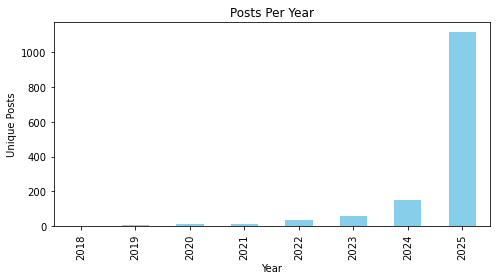

In [28]:
# Filter for years >= 2018
df_filtered = df[df["year"] >= 2018]

# Group by year and count unique post_ids
yearly_posts = df_filtered.groupby("year")["post_id"].nunique()

# Plot only if there's data
if not yearly_posts.empty:
    plt.figure(figsize=(7, 4))
    yearly_posts.plot(kind="bar", title="Posts Per Year", color="skyblue")
    plt.ylabel("Unique Posts")
    plt.xlabel("Year")
    plt.tight_layout()
    plt.show()
else:
    print("No data available from 2018 onwards.")


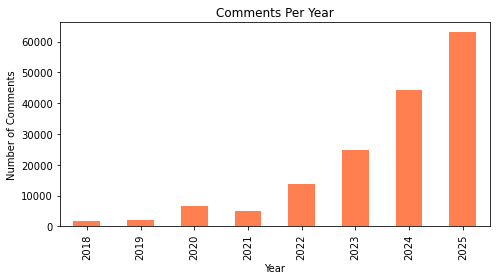

In [29]:
df_filtered = df[df["year"] >= 2018]

# Group by year and count the number of comments
yearly_comments = df_filtered.groupby("year")["comment_body"].count()

# Plot only if data exists
if not yearly_comments.empty:
    plt.figure(figsize=(7, 4))
    yearly_comments.plot(kind="bar", title="Comments Per Year", color="coral")
    plt.ylabel("Number of Comments")
    plt.xlabel("Year")
    plt.tight_layout()
    plt.show()

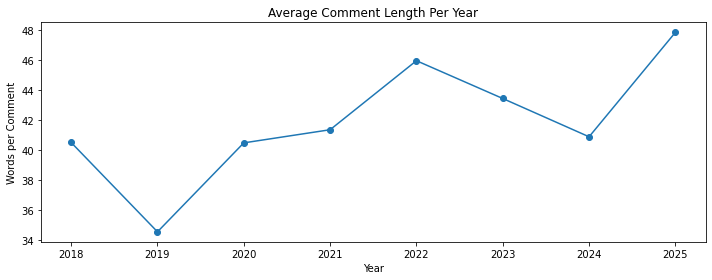

In [30]:
df_filtered = df[df["year"] >= 2018]

# Compute comment length
df_filtered["comment_length"] = df_filtered["comment_body"].apply(lambda x: len(str(x).split()))

# Group by year and compute average comment length
avg_comment_len = df_filtered.groupby("year")["comment_length"].mean()

# Plot only if data exists
if not avg_comment_len.empty:
    plt.figure(figsize=(10, 4))
    avg_comment_len.plot(kind="line", marker="o", title="Average Comment Length Per Year")
    plt.ylabel("Words per Comment")
    plt.xlabel("Year")
    plt.tight_layout()
    plt.show()

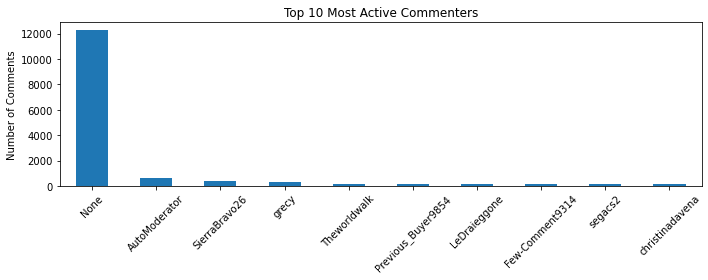

In [14]:
top_users = df["comment_author"].value_counts().head(10)
plt.figure(figsize=(10, 4))
top_users.plot(kind="bar", title="Top 10 Most Active Commenters")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

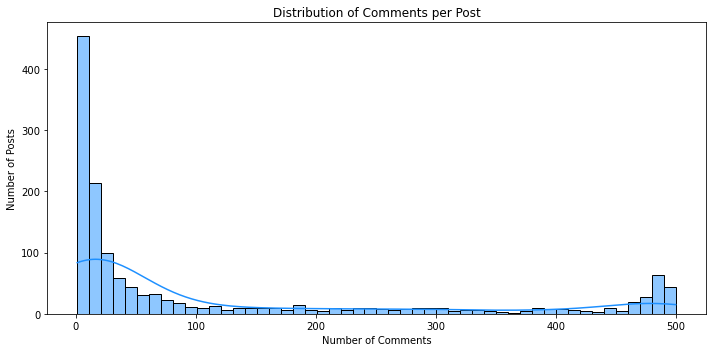

In [15]:
comments_per_post = df.groupby("post_id")["comment_body"].count()

plt.figure(figsize=(10, 5))
sns.histplot(comments_per_post, bins=50, kde=True, color="dodgerblue")
plt.title("Distribution of Comments per Post")
plt.xlabel("Number of Comments")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

EDA for yt data

In [16]:
yt_df = pd.read_csv("Datasets/yt_comments.csv")
yt_df

,video_id,video_title,video_like_count,video_view_count,comment_id,author,comment,timestamp,comment_like_count,reply_count,reply_id,reply_text,reply_author,reply_published
0,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,UgzBbjwRou6cSNwX9Ot4AaABAg,@Recondo1967,Amazing content. I’m going to Bali this year s...,2025-01-01 19:24:46,3,2,UgzBbjwRou6cSNwX9Ot4AaABAg.AClMa4zgQZyAClOCW6z5gW,You absolutely should! I hope you have a great...,@KevinEassa,2025-01-01T19:38:53Z
1,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,UgzBbjwRou6cSNwX9Ot4AaABAg,@Recondo1967,Amazing content. I’m going to Bali this year s...,2025-01-01 19:24:46,3,2,UgzBbjwRou6cSNwX9Ot4AaABAg.AClMa4zgQZyAEfI3Hk07ez,"try getting a travel guide before going, wishi...",@abolajiibrahim299,2025-02-18T03:52:32Z
2,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,Ugzdznl-nh_LZLIdsoh4AaABAg,@bestplaces_to_visit,"This video is stunning. After watching, does a...",2025-03-01 03:48:16,3,0,NaN,NaN,NaN,NaN
3,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,UgwSzhkR3E0iHPZ6kQx4AaABAg,@dxnsheger972,"Im planning to visit Georgia,Malaysia,Turkey a...",2025-03-29 19:58:46,2,1,UgwSzhkR3E0iHPZ6kQx4AaABAg.AGGRdK1uQMTAGQ2qtIYLy6,That’s going to be an amazing trip!,@KevinEassa,2025-04-02T13:34:34Z
4,40W27HZCcso,Top 15 Countries to Visit in 2025 | Ultimate T...,443,37613,UgxL7G8ahHsF5naHmJ94AaABAg,@breezydaysahead,Happy new year! 2025 is gonna be sick,2025-01-01 17:48:00,2,1,UgxL7G8ahHsF5naHmJ94AaABAg.AClBWMXLvThAClHWiIKu6o,Can’t wait to see what all we get up to ❤️,@KevinEassa,2025-01-01T18:40:28Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4044,lToZ-Fx4Dro,Top 10 Countries I Want to Visit Someday,5,111,Ugh_EZBch1kisngCoAEC,@opheliatellsstories8360,"traveling is sooo good, I love this! :) xx",2015-08-23 16:12:53,1,1,Ugh_EZBch1kisngCoAEC.83CMn9O6dSs7-HyLfLSkfg,Thanks!(:,@AShootingStar434,2015-08-24T01:04:04Z
4045,lToZ-Fx4Dro,Top 10 Countries I Want to Visit Someday,5,111,UghUgsKBAFcRWHgCoAEC,@KenzieLillian,I would love to go to almost all of these plac...,2015-08-23 04:34:37,1,1,UghUgsKBAFcRWHgCoAEC.83B6sv2l0vF7-H4ALnRLTL,+KenzieLillian I always wanted to go to Italy xDD,@AShootingStar434,2015-08-23T05:06:11Z
4046,lToZ-Fx4Dro,Top 10 Countries I Want to Visit Someday,5,111,UgjQYyTlR-aiFXgCoAEC,@brianat1570,Love this so much.,2015-08-22 23:33:00,1,1,UgjQYyTlR-aiFXgCoAEC.83A_MlzHH3B7-H1h8aglk1,Thanks!(:,@AShootingStar434,2015-08-22T23:42:58Z
4047,lToZ-Fx4Dro,Top 10 Countries I Want to Visit Someday,5,111,Ugj6MAdXVuG_ZHgCoAEC,@kenzierules1207,London and Australia are my top places,2015-08-25 06:53:49,1,0,NaN,NaN,NaN,NaN


In [17]:
yt_df.shape

(4049, 14)

In [18]:
yt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4049 entries, 0 to 4048
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   video_id            4049 non-null   object
 1   video_title         4049 non-null   object
 2   video_like_count    4049 non-null   int64 
 3   video_view_count    4049 non-null   int64 
 4   comment_id          4049 non-null   object
 5   author              4049 non-null   object
 6   comment             4048 non-null   object
 7   timestamp           4049 non-null   object
 8   comment_like_count  4049 non-null   int64 
 9   reply_count         4049 non-null   int64 
 10  reply_id            2597 non-null   object
 11  reply_text          2596 non-null   object
 12  reply_author        2595 non-null   object
 13  reply_published     2597 non-null   object
dtypes: int64(4), object(10)
memory usage: 443.0+ KB


In [19]:
yt_df.isnull().sum()

video_id                 0
video_title              0
video_like_count         0
video_view_count         0
comment_id               0
author                   0
comment                  1
timestamp                0
comment_like_count       0
reply_count              0
reply_id              1452
reply_text            1453
reply_author          1454
reply_published       1452
dtype: int64

In [33]:
# Ensure timestamp is in datetime format
yt_df["timestamp"] = pd.to_datetime(yt_df["timestamp"], errors="coerce")

# Extract year
yt_df["year"] = yt_df["timestamp"].dt.year

# Preview
print(yt_df[["timestamp", "year"]].head())


            timestamp  year
0 2025-01-01 19:24:46  2025
1 2025-01-01 19:24:46  2025
2 2025-03-01 03:48:16  2025
3 2025-03-29 19:58:46  2025
4 2025-01-01 17:48:00  2025


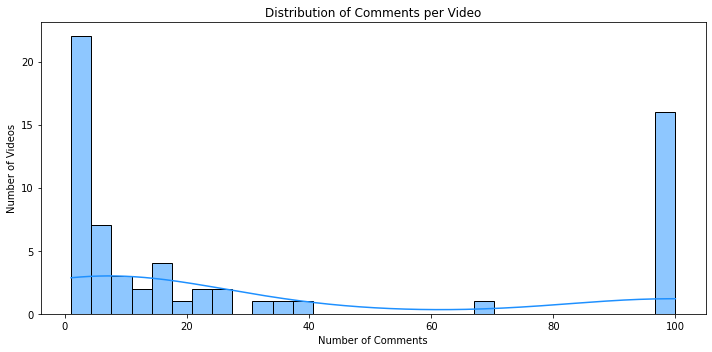

count     63.000000
mean      33.095238
std       40.857626
min        1.000000
25%        3.000000
50%        8.000000
75%       83.000000
max      100.000000
Name: comment_id, dtype: float64


In [34]:
comment_counts = yt_df.groupby("video_id")["comment_id"].nunique()

plt.figure(figsize=(10, 5))
sns.histplot(comment_counts, bins=30, kde=True, color="dodgerblue")
plt.title("Distribution of Comments per Video")
plt.xlabel("Number of Comments")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

print(comment_counts.describe())

In [36]:
# Count unique comments per video per year
comments_per_video = yt_df.groupby(["year", "video_id", "video_title"])["comment_id"].nunique().reset_index()
comments_per_video.rename(columns={"comment_id": "comment_count"}, inplace=True)

# Get most commented video for each year
most_commented_per_year = comments_per_video.loc[comments_per_video.groupby("year")["comment_count"].idxmax()].reset_index(drop=True)
most_commented_per_year

,year,video_id,video_title,comment_count
0,2015,mgts8_L2xlk,Top 10 Best countries to visit in 2015,14
1,2016,d1ojTfHsNio,The best country to travel to in 2017 - Lonely...,47
2,2017,d1ojTfHsNio,The best country to travel to in 2017 - Lonely...,44
3,2018,Smh8I18DKLQ,Top 10 countries to visit in 2019 - Lonely Pla...,37
4,2019,opD8Uq62v5I,Finland Is The Best Country To Travel To In 2019,55
5,2020,Nf9Gtmxpe0k,Greece Is Insider&#39;s No. 1 Country To Visit...,99
6,2021,oEnQkKWOJDQ,Top 10 African Countries to Visit in 2021 | Mo...,55
7,2022,UWKhvzdnctY,15 Best Countries to Visit in Asia - Travel Video,43
8,2023,lH_FJ6N_Wvw,Top 10 Best Countries To Visit In Asia 2023 | ...,58
9,2024,zjhtj7r_AvE,The Top 5 Countries YOU Should Visit in 2024! ...,91


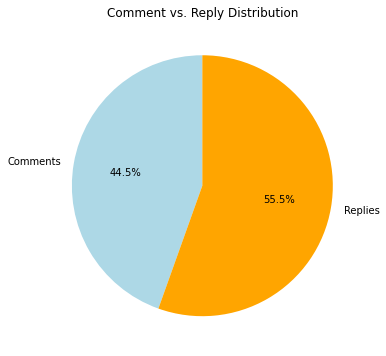

Comments: 2085, Replies: 2597


In [38]:
total_comments = yt_df["comment_id"].nunique()
total_replies = yt_df["reply_id"].notna().sum()

labels = ["Comments", "Replies"]
sizes = [total_comments, total_replies]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=["lightblue", "orange"])
plt.title("Comment vs. Reply Distribution")
plt.show()

print(f"Comments: {total_comments}, Replies: {total_replies}")
